In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import enum
from typing import List, NamedTuple

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import scienceplots  # noqa: F401
import seaborn as sns
from scipy.stats import entropy

from utils import DATADIR, load_data_per_event

plt.style.use(["science", "ieee"])

In [2]:
class TransitionMatrix(enum.Enum):
    BEFORE = "before"
    AFTER = "after"
    ALL = "all"

    @staticmethod
    def __transition_matrix(df: pl.DataFrame) -> pl.DataFrame:
        transitions = (
            df.select("primordial")
            .with_columns(
                pl.col("primordial").alias("from_state"),
                pl.col("primordial").shift(-1).alias("to_state"),
            )
            .drop_nulls()
        )

        # Count transitions
        counts = transitions.group_by(["from_state", "to_state"]).agg(
            pl.len().alias("count")
        )

        # Ensure all G1/G2/G3 pairs exist (even if 0)
        states = ["G1", "G2", "G3"]
        all_pairs = pl.DataFrame(
            {
                "from_state": [s for s in states for _ in states],
                "to_state": [s for _ in states for s in states],
            }
        )

        counts_full = all_pairs.join(
            counts, on=["from_state", "to_state"], how="left"
        ).fill_null(0)

        # Calculate probabilities (each row sums to 1)
        row_totals = counts_full.group_by("from_state").agg(
            pl.col("count").sum().alias("total")
        )

        prob_matrix = (
            counts_full.join(row_totals, on="from_state")
            .with_columns((pl.col("count") / pl.col("total")).alias("prob"))
            .select(["from_state", "to_state", "prob"])
            .pivot(on="to_state", index="from_state", values="prob")
            .sort("from_state")
            .select(["from_state"] + states)  # Order columns as G1, G2, G3
        )

        return prob_matrix

    def transition_matrix(self, df: pl.DataFrame) -> pl.DataFrame:
        if self == TransitionMatrix.BEFORE:
            df = df.filter(pl.col("t2") <= 0)
            return self.__transition_matrix(df)
        elif self == TransitionMatrix.AFTER:
            df = df.filter(pl.col("t2") > 0)
            return self.__transition_matrix(df)
        elif self == TransitionMatrix.ALL:
            return self.__transition_matrix(df)
        else:
            raise ValueError(f"Unknown transition matrix: {self}")


class EventData(NamedTuple):
    event_class: str
    event_tm: nx.DiGraph
    tm_thecnique: str


In [3]:
%%capture
events: List[EventData] = []

for year_event in list(filter(lambda x: x.is_dir(), DATADIR.glob("*"))):
    print(f"[+] Processing year: {year_event.name}")
    year_metadata = year_event / "event_metadata.csv"
    metadata = pl.read_csv(year_metadata)
    for event in year_event.glob("*.txt"):
        event_id = event.stem
        event_class = str(
            metadata.filter(pl.col("#") == int(event_id))["class"].item()[0]
        )
        print(f"  [+] Processing event: {event_id} -- class: {event_class}")

        df = load_data_per_event(event).drop_nulls().drop_nans()
        primordial = []
        for i, row in enumerate(df.iter_rows(named=True)):
            try:
                if (
                    row["G3bgsub"] >= row["G2bgsub"]
                    and row["G3bgsub"] >= row["G1bgsub"]
                ):
                    primordial.append("G3")
                elif (
                    row["G2bgsub"] >= row["G1bgsub"]
                    and row["G2bgsub"] >= row["G3bgsub"]
                ):
                    primordial.append("G2")
                elif (
                    row["G1bgsub"] >= row["G3bgsub"]
                    and row["G1bgsub"] >= row["G2bgsub"]
                ):
                    primordial.append("G1")
                else:
                    print(
                        f"  [!] Skipping row with NaN values ({i}) for event {event_id}: {row}"
                    )
            except TypeError:
                print(
                    f"  [!] Skipping row with NaN values ({i}) for event {event_id}: {row}"
                )

        try:
            df = df.with_columns(pl.Series("primordial", primordial))
        except Exception:
            display(df)
            display(len(primordial))
            raise

        for tm in TransitionMatrix:
            print(f"    [?] Transition Matrix: {tm.value}")
            prob_matrix = (
                (
                    tm.transition_matrix(df)
                    .fill_null(0.0)
                    .fill_nan(0.0)
                    .sort("from_state")
                    .select(["from_state"] + ["G1", "G2", "G3"])
                )
                .to_pandas()
                .replace({0: 1e-6})
            )

            graph = nx.from_pandas_adjacency(
                prob_matrix.set_index("from_state"), create_using=nx.DiGraph
            )
            events.append((event_class, graph, tm.value))  # type: ignore

In [4]:
events_df = pl.DataFrame(events, schema=["event_class", "transition_matrix", "tm_technique"])
events_df

/tmp/ipykernel_475649/850046362.py:1: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  events_df = pl.DataFrame(events, schema=["event_class", "transition_matrix", "tm_technique"])


event_class,transition_matrix,tm_technique
str,object,str
"""M""",DiGraph with 3 nodes and 9 edges,"""before"""
"""M""",DiGraph with 3 nodes and 9 edges,"""after"""
"""M""",DiGraph with 3 nodes and 9 edges,"""all"""
"""M""",DiGraph with 3 nodes and 9 edges,"""before"""
"""M""",DiGraph with 3 nodes and 9 edges,"""after"""
…,…,…
"""M""",DiGraph with 3 nodes and 9 edges,"""after"""
"""M""",DiGraph with 3 nodes and 9 edges,"""all"""
"""X""",DiGraph with 3 nodes and 9 edges,"""before"""


In [91]:
# Linear algebra features
eigenvalues = [
    np.linalg.eigvals(nx.adjacency_matrix(g).toarray())
    for g in events_df["transition_matrix"]
]
traces = [
    np.linalg.trace(nx.adjacency_matrix(g).toarray())
    for g in events_df["transition_matrix"]
]

# For entropies could be a good idea to get the average, but I'll keep the list for now
entropies = [
    entropy(nx.adjacency_matrix(G).toarray(), axis=1)
    for G in events_df["transition_matrix"]
]

# Eigenvector centrality {'G1': ..., 'G2': ..., 'G3': ...}
eigenvector_centralities = [
    nx.eigenvector_centrality_numpy(g) for g in events_df["transition_matrix"]
]

events_df = events_df.with_columns(
    pl.Series("eigenvalues", eigenvalues, dtype=pl.Object),
    pl.Series("traces", traces),
    pl.Series("entropies", entropies, dtype=pl.Object),
    pl.Series("eigenvector_centralities", eigenvector_centralities, dtype=pl.Object),
)

In [92]:
events_df

event_class,transition_matrix,tm_technique,eigenvalues,traces,entropies,eigenvector_centralities
str,object,str,object,f64,object,object
"""M""",DiGraph with 3 nodes and 9 edges,"""before""",[ 1. 0.13710526 -0.01644345],1.120662,[1.04303238 1.09504922 1.0929078 ],"{'G1': 0.5773502691896257, 'G2': 0.5773502691896257, 'G3': 0.5773502691896257}"
"""M""",DiGraph with 3 nodes and 9 edges,"""after""",[ 1.00000000e+00 1.99999800e-06 -1.63957553e-38],1.000002,[2.96309639e-05 1.09861229e+00 1.09861229e+00],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
"""M""",DiGraph with 3 nodes and 9 edges,"""all""",[ 1. 0.59661803 -0.01821192],1.578406,[0.22353346 1.09504922 1.0929078 ],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
"""M""",DiGraph with 3 nodes and 9 edges,"""before""",[ 1. 0.13466909 -0.01885735],1.115812,[0.87807929 1.04767462 0.9973292 ],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
"""M""",DiGraph with 3 nodes and 9 edges,"""after""",[1. 0.17566712 0.02352438],1.199191,[0.29214682 0.66966557 0.7666534 ],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
…,…,…,…,…,…,…
"""M""",DiGraph with 3 nodes and 9 edges,"""after""",[ 1. 0.3815566 -0.00850392],1.373053,[0.34621687 0.97027834 1.04844601],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
"""M""",DiGraph with 3 nodes and 9 edges,"""all""",[1. 0.38472333 0.01510868],1.399832,[0.41217048 0.99262972 1.06310668],"{'G1': 0.5773502691896257, 'G2': 0.5773502691896257, 'G3': 0.5773502691896257}"
"""X""",DiGraph with 3 nodes and 9 edges,"""before""",[ 1. 0.28016229 -0.12082316],1.159339,[0.85925168 1.07691931 1.07768174],"{'G1': 0.5773502691896257, 'G2': 0.5773502691896257, 'G3': 0.5773502691896257}"


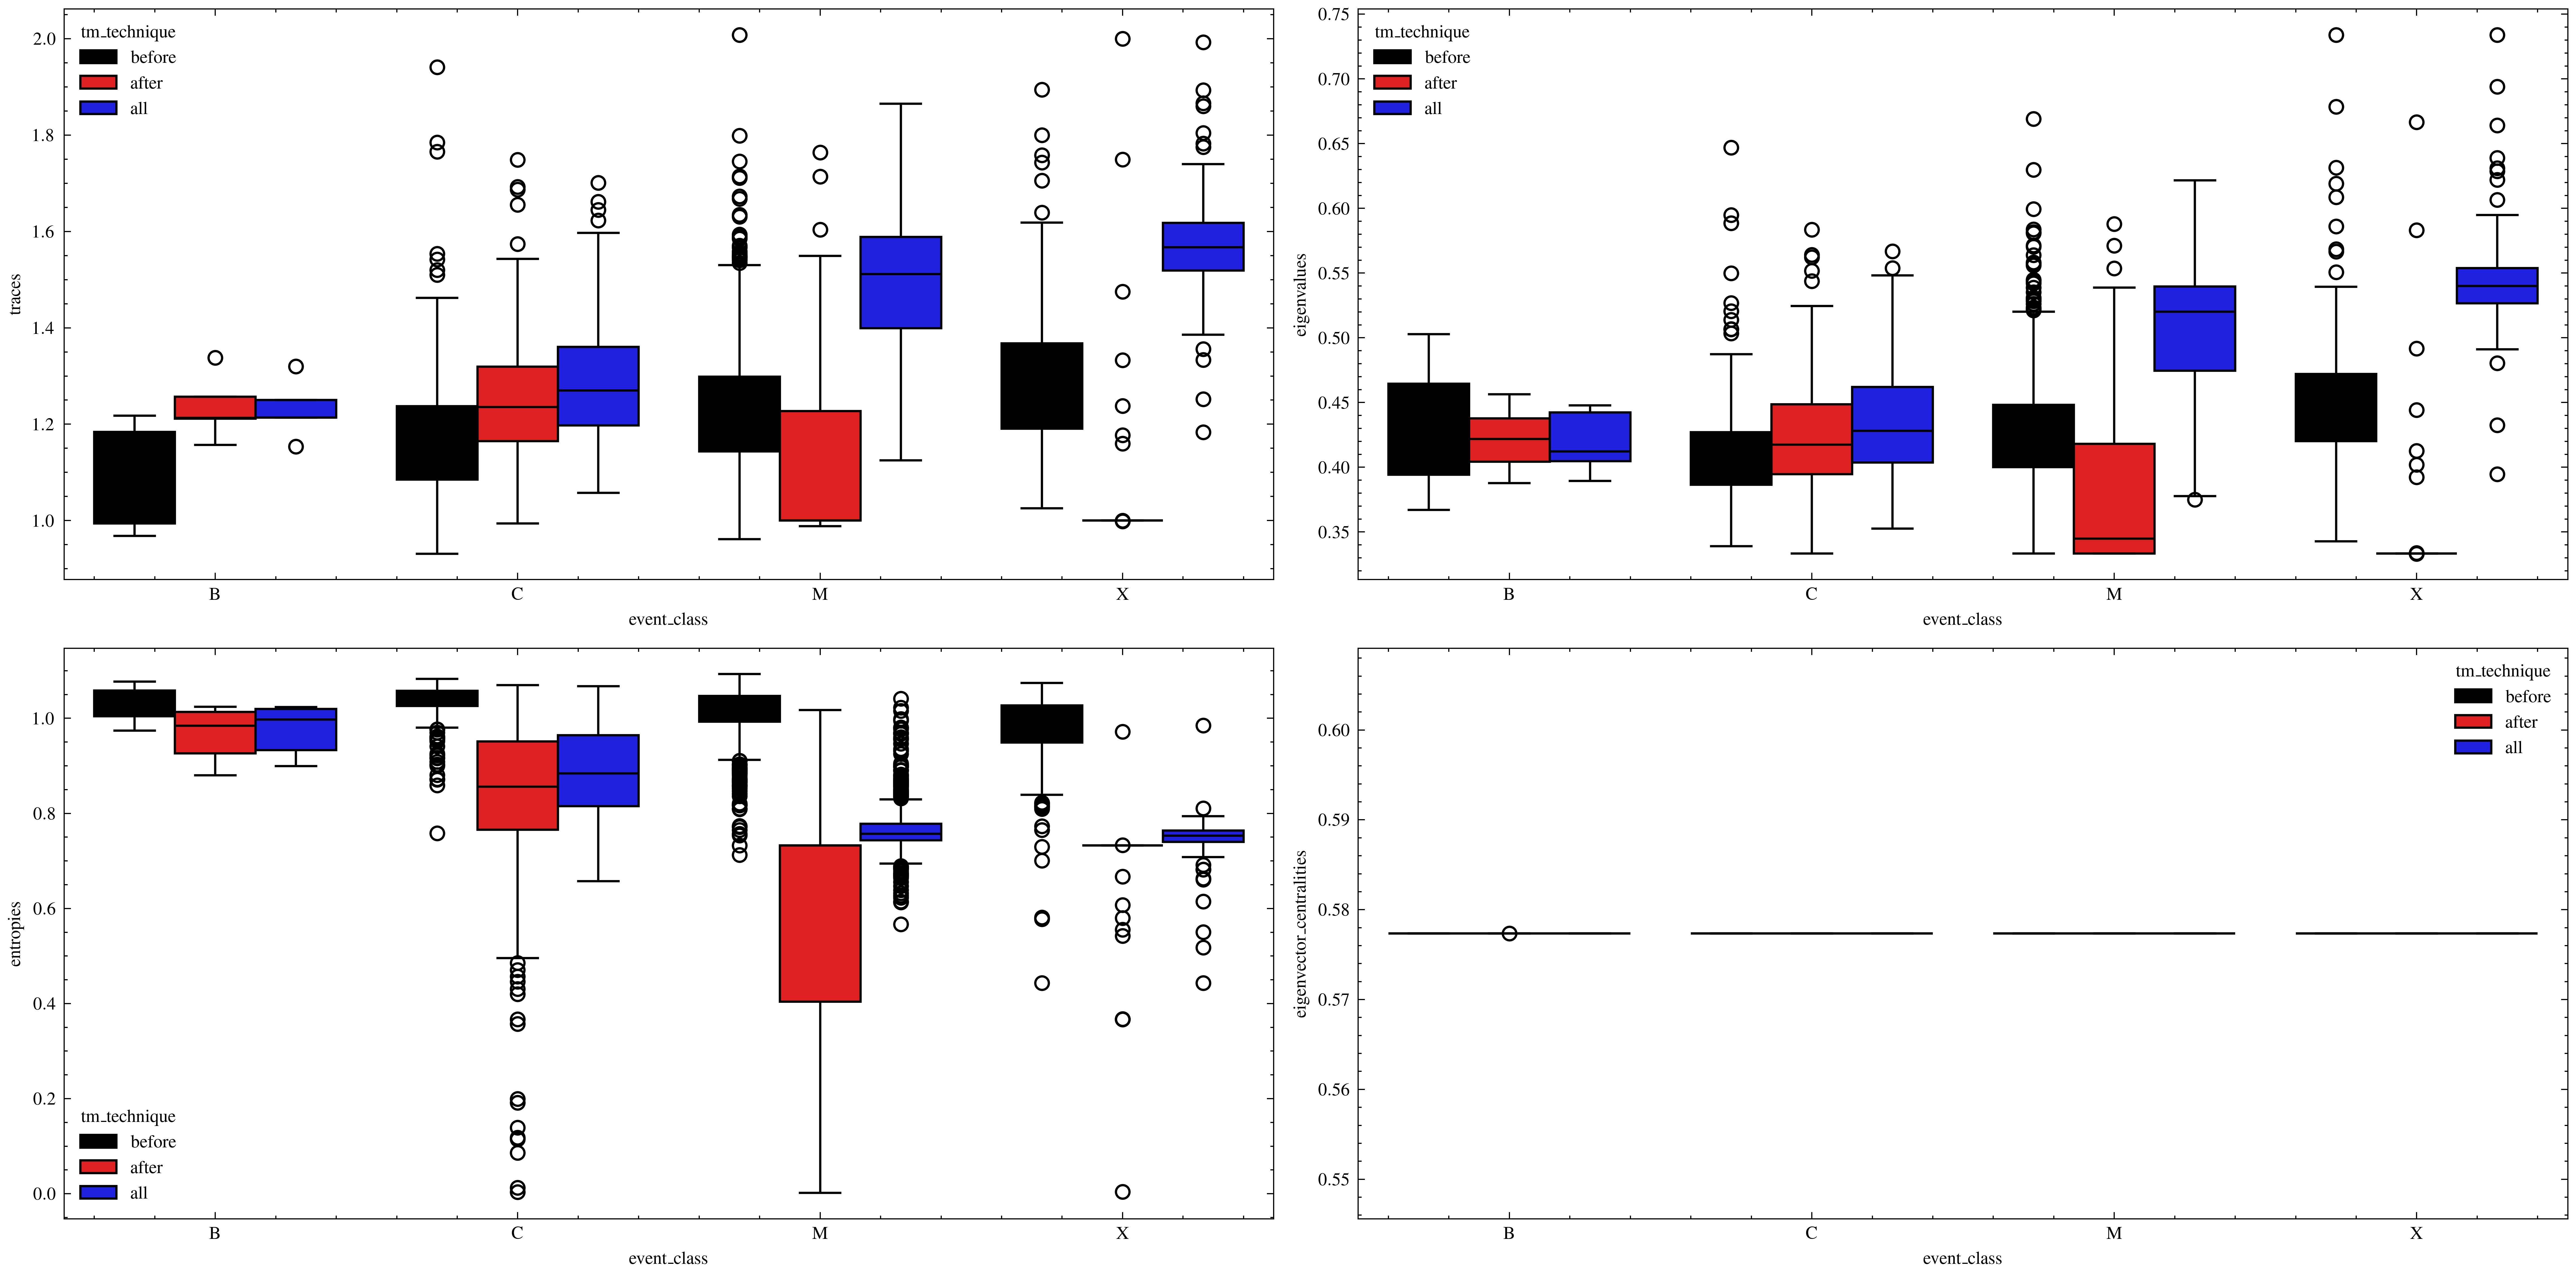

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plot_data = events_df.to_pandas()
plot_data = plot_data.sort_values("event_class")

sns.boxplot(
    data=plot_data, x="event_class", y="traces", hue="tm_technique", ax=axes[0, 0]
)
sns.boxplot(
    data=plot_data,
    x="event_class",
    y=plot_data["eigenvalues"].apply(lambda x: np.mean(np.abs(x))),
    hue="tm_technique",
    ax=axes[0, 1],
)
sns.boxplot(
    data=plot_data,
    x="event_class",
    y=plot_data["entropies"].apply(lambda x: np.mean(x)),
    hue="tm_technique",
    ax=axes[1, 0],
)
sns.boxplot(
    data=plot_data,
    x="event_class",
    y=plot_data["eigenvector_centralities"].apply(lambda x: np.mean(list(x.values()))),
    hue="tm_technique",
    ax=axes[1, 1],
)

plt.tight_layout()
plt.show()